In [14]:
df.shape

(3650, 7)

In [15]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   날짜      3650 non-null   object
 1   순위      3650 non-null   object
 2   영화명     3650 non-null   object
 3   개봉일     3650 non-null   object
 4   일일관객수   3650 non-null   object
 5   누적관객수   3650 non-null   object
 6   일일매출액   3650 non-null   object
dtypes: object(7)
memory usage: 199.7+ KB


,날짜,순위,영화명,개봉일,일일관객수,누적관객수,일일매출액
0,20250101,1,하얼빈,2024-12-24,340484,3095720,3290065760
1,20250101,2,보고타: 마지막 기회의 땅,2024-12-31,93154,194095,880276910
2,20250101,3,소방관,2024-12-04,80830,3398126,769063260
3,20250101,4,수퍼 소닉3,2025-01-01,75916,97373,705207940
4,20250101,5,뽀로로 극장판 바닷속 대모험,2025-01-01,58882,92837,512345060


- 월별 박스오피스 1등 리스트업

In [18]:
# df 객체를 파일로 저장
df.to_csv('data/kobis.csv', encoding='utf-8', index=False)

In [ ]:
df.dtypes

# '날짜' 컬럼의 데이터타입 변경 - datime
df['날짜'] = pd.to_datetime(df['날짜'])
df.dtypes

# 년, 월, 일, 요일 컬럼 생성
df['연도'] = df['날짜'].dt.year
df['월'] = df['날짜'].dt.month
df['일'] = df['날짜'].dt.day
df['요일'] = df['날짜'].dt.weekday
df

In [25]:
# 요일 변경
week_dict = {
     0: '월',
     1: '화',
     2: '수',
     3: '목',
     4: '금',
     5: '토',
     6: '일'
}
df['요일'] = df['날짜'].dt.weekday.map(week_dict)
df['요일'].value_counts()

요일
수    530
목    520
금    520
토    520
일    520
월    520
화    520
Name: count, dtype: int64

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   날짜      3650 non-null   datetime64[ns]
 1   순위      3650 non-null   object        
 2   영화명     3650 non-null   object        
 3   개봉일     3650 non-null   object        
 4   일일관객수   3650 non-null   object        
 5   누적관객수   3650 non-null   object        
 6   일일매출액   3650 non-null   object        
 7   연도      3650 non-null   int32         
 8   월       3650 non-null   int32         
 9   일       3650 non-null   int32         
 10  요일      3650 non-null   object        
dtypes: datetime64[ns](1), int32(3), object(7)
memory usage: 271.0+ KB


In [28]:
df

,날짜,순위,영화명,개봉일,일일관객수,누적관객수,일일매출액,연도,월,일,요일
0,2025-01-01,1,하얼빈,2024-12-24,340484,3095720,3290065760,2025,1,1,수
1,2025-01-01,2,보고타: 마지막 기회의 땅,2024-12-31,93154,194095,880276910,2025,1,1,수
2,2025-01-01,3,소방관,2024-12-04,80830,3398126,769063260,2025,1,1,수
3,2025-01-01,4,수퍼 소닉3,2025-01-01,75916,97373,705207940,2025,1,1,수
4,2025-01-01,5,뽀로로 극장판 바닷속 대모험,2025-01-01,58882,92837,512345060,2025,1,1,수
...,...,...,...,...,...,...,...,...,...,...,...
3645,2025-12-31,6,극장판 짱구는 못말려: 초화려! 작열하는 떡잎마을 댄서즈,2025-12-24,18979,327390,154747310,2025,12,31,수
3646,2025-12-31,7,화양연화 특별판,2025-12-31,9292,11279,80027452,2025,12,31,수
3647,2025-12-31,8,뽀로로 극장판 스위트캐슬 대모험,2025-12-11,4807,216003,41105520,2025,12,31,수
3648,2025-12-31,9,누벨바그,2025-12-31,4051,4597,24782960,2025,12,31,수


In [49]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import platform

if platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='DejaVu Sans')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print('NumPy 버전:', np.__version__)
print('환경 설정 완료')

NumPy 버전: 2.3.5
환경 설정 완료


In [ ]:
df['순위'].value_counts()
df_rank1 = df[df['순위'] == '1']
df_rank1

# 2025년 기준 Top of Top 10   
df['일일관객수'] = df['일일관객수'].astype(int)
df['일일관객수'].dtypes
df_rank1_top10 = df.groupby('영화명')['일일관객수'].sum().sort_values(ascending=False).head(10)
df_rank1_top10

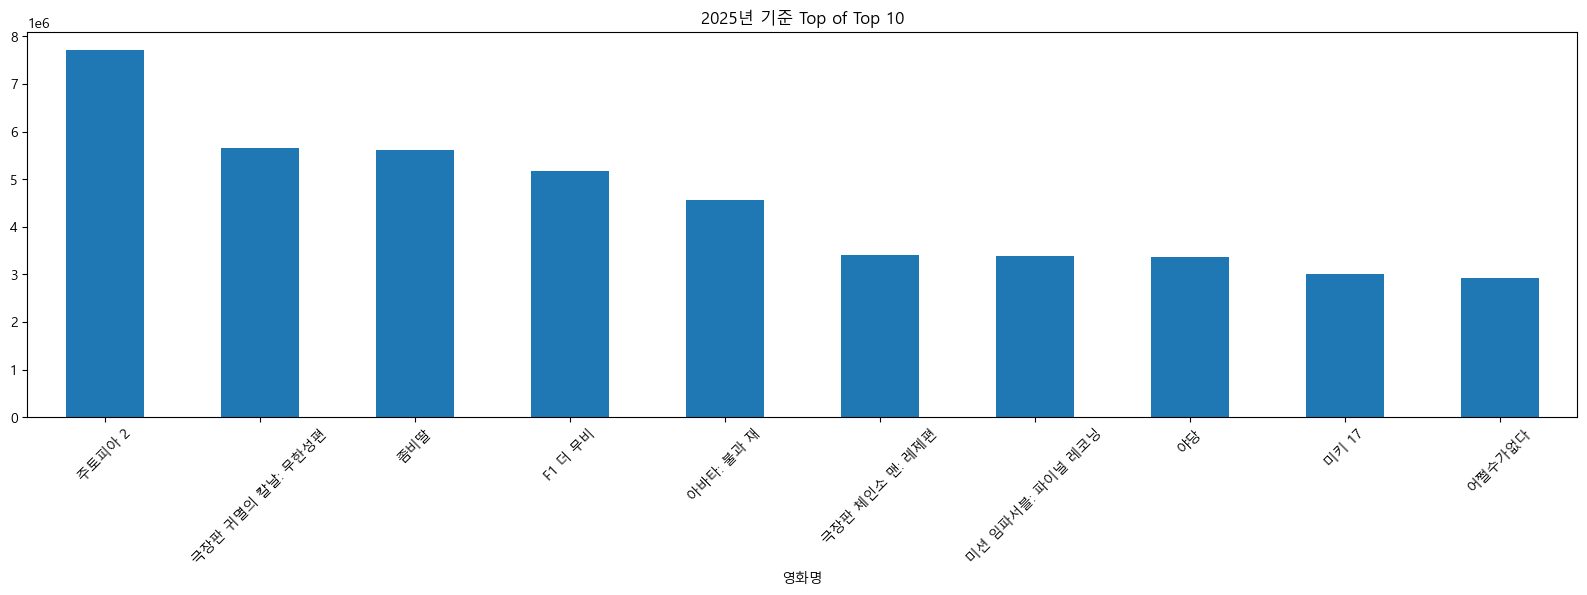

In [53]:
# 2025년 기준 Top of Top 10 그래프
import matplotlib.pyplot as plt

df_rank1_top10.plot(
    kind='bar',
    figsize = (20, 5)
)
plt.title('2025년 기준 Top of Top 10')
plt.xticks(rotation=45)
plt.show()

- 월별 총 매출액 기준 Top10
- 그래프 생성 시 월별로 정렬(1월 ~ 12월)

In [56]:
df['일일매출액'] = df['일일매출액'].astype(int) 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   날짜      3650 non-null   datetime64[ns]
 1   순위      3650 non-null   object        
 2   영화명     3650 non-null   object        
 3   개봉일     3650 non-null   object        
 4   일일관객수   3650 non-null   int64         
 5   누적관객수   3650 non-null   object        
 6   일일매출액   3650 non-null   int64         
 7   연도      3650 non-null   int32         
 8   월       3650 non-null   int32         
 9   일       3650 non-null   int32         
 10  요일      3650 non-null   object        
dtypes: datetime64[ns](1), int32(3), int64(2), object(5)
memory usage: 271.0+ KB


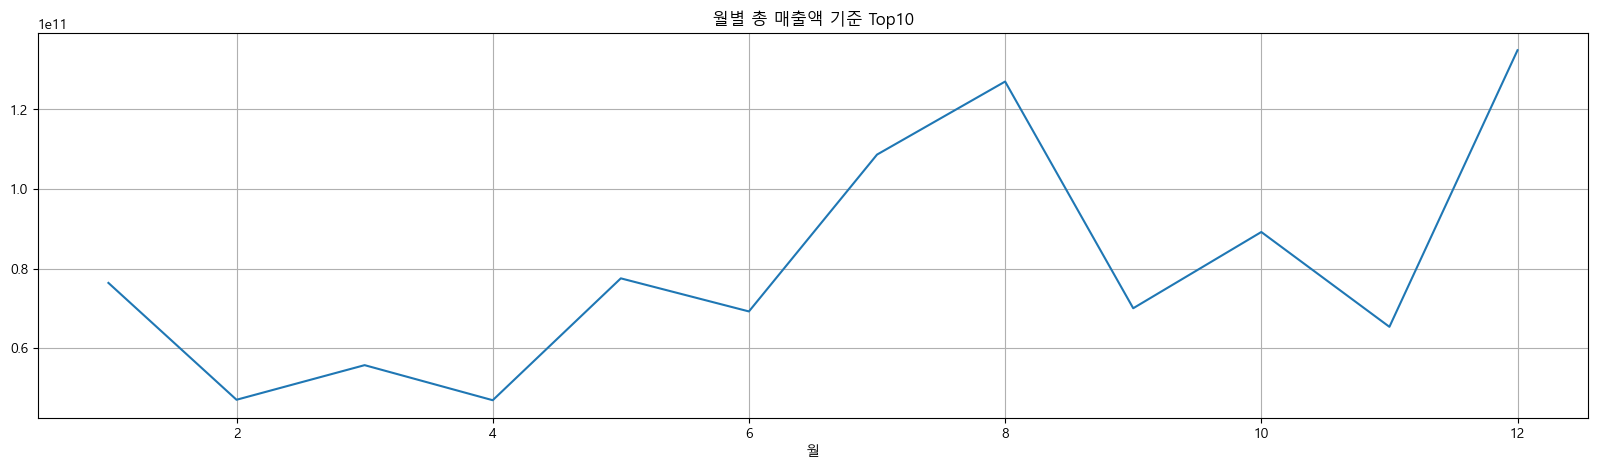

In [65]:
df_month = df.groupby('월')['일일매출액'].sum()
df_month

df_month.plot(
    kind='line',
    figsize= (20,5)
)
plt.title('월별 총 매출액 기준 Top10')
plt.grid()
plt.show()

- 요일별 일일 관객수 추이

In [ ]:
df.info()

In [ ]:
df['요일'].value_counts()

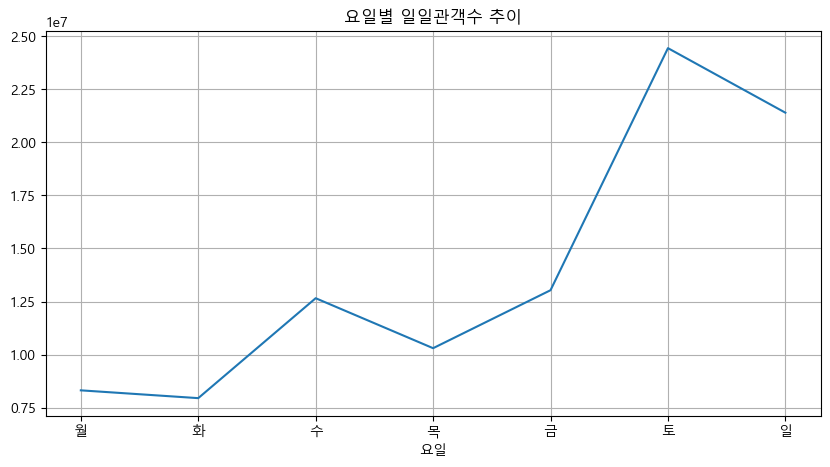

In [80]:
weekday = ['월','화','수','목','금','토','일']
df_weekday = df.groupby('요일')['일일관객수'].sum().reindex(weekday)
df_weekday

df_weekday.plot(
    kind='line',
    figsize= (10,5)
)
plt.title('요일별 일일관객수 추이')
plt.ylabel('일일 관객수')
plt.grid()
plt.show()